In [2]:
import pandas as pd
import numpy as np
print("everything working")
print(pd.__version__)
print(np.__version__)

everything working
2.2.2
2.0.2


In [5]:
from google.colab import files
uploaded = files.upload()

Saving city_day.csv to city_day.csv


In [6]:
df = pd.read_csv('city_day.csv')
print(df.shape)
df.head()

(29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [7]:
# Get a full picture of the dataset
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nNull values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (29531, 16)

Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Null values:
 City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Data types:
 City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


In [10]:
df = df.drop(columns=['Xylene', 'NH3', 'PM10'])

KeyError: "['Xylene', 'NH3', 'PM10'] not found in axis"

In [11]:
# Fill remaining null AQI values with city average
df['AQI'] = df.groupby('City')['AQI'].transform(
    lambda x: x.fillna(x.mean())
)

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract month and year from date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

# Check nulls again
print("Nulls after cleaning:\n", df.isnull().sum())
print("\nShape after cleaning:", df.shape)

Nulls after cleaning:
 City             0
Date             0
PM2.5         4598
NO            3582
NO2           3585
NOx           4185
CO            2059
SO2           3854
O3            4022
Benzene       5623
Toluene       8041
AQI              0
AQI_Bucket    4681
Year             0
Month            0
dtype: int64

Shape after cleaning: (29531, 15)


In [12]:
# Fill PM2.5 with city average (important pollutant)
df['PM2.5'] = df.groupby('City')['PM2.5'].transform(
    lambda x: x.fillna(x.mean())
)

# Drop columns we don't need for analysis
df = df.drop(columns=['NO', 'NO2', 'NOx', 'CO',
                       'SO2', 'O3', 'Benzene', 'Toluene', 'AQI_Bucket'])

# Final check
print("Final nulls:\n", df.isnull().sum())
print("Final shape:", df.shape)
print("\nClean dataset preview:")
df.head()

Final nulls:
 City     0
Date     0
PM2.5    0
AQI      0
Year     0
Month    0
dtype: int64
Final shape: (29531, 6)

Clean dataset preview:


,City,Date,PM2.5,AQI,Year,Month
0,Ahmedabad,2015-01-01,67.854497,452.122939,2015,January
1,Ahmedabad,2015-01-02,67.854497,452.122939,2015,January
2,Ahmedabad,2015-01-03,67.854497,452.122939,2015,January
3,Ahmedabad,2015-01-04,67.854497,452.122939,2015,January
4,Ahmedabad,2015-01-05,67.854497,452.122939,2015,January


In [13]:
# 1. Most polluted cities on average
print("Top 10 Most Polluted Cities:")
print(df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10))

# 2. Worst month for air quality
print("\nAQI by Month:")
print(df.groupby('Month')['AQI'].mean().sort_values(ascending=False))

# 3. AQI trend by year
print("\nAQI by Year:")
print(df.groupby('Year')['AQI'].mean().sort_values(ascending=False))

Top 10 Most Polluted Cities:
City
Ahmedabad       452.122939
Delhi           259.487744
Patna           240.782042
Gurugram        225.123882
Lucknow         217.973059
Talcher         172.886819
Jorapokhar      159.251621
Brajrajnagar    150.280505
Kolkata         140.566313
Guwahati        140.111111
Name: AQI, dtype: float64

AQI by Month:
Month
November     235.012827
January      225.546280
December     222.028720
February     201.256037
October      183.084023
March        167.686823
April        149.113975
May          144.272968
June         131.839786
September    127.530941
August       124.878914
July         124.426822
Name: AQI, dtype: float64

AQI by Year:
Year
2016    205.102639
2015    199.132393
2017    190.261521
2018    178.325787
2019    155.379158
2020    114.282183
Name: AQI, dtype: float64


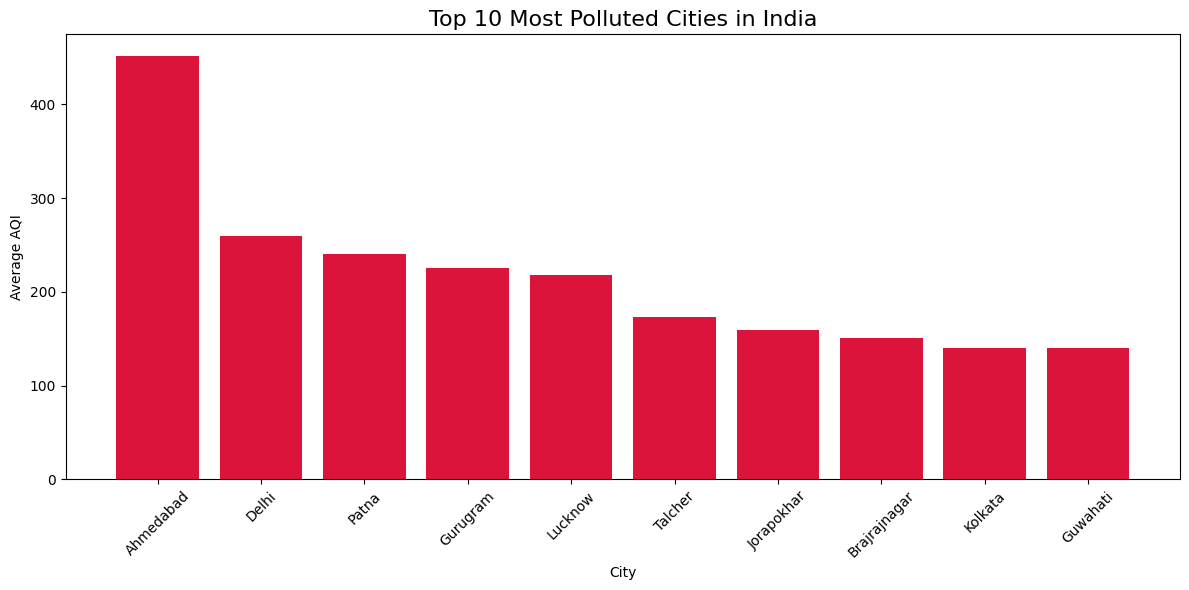

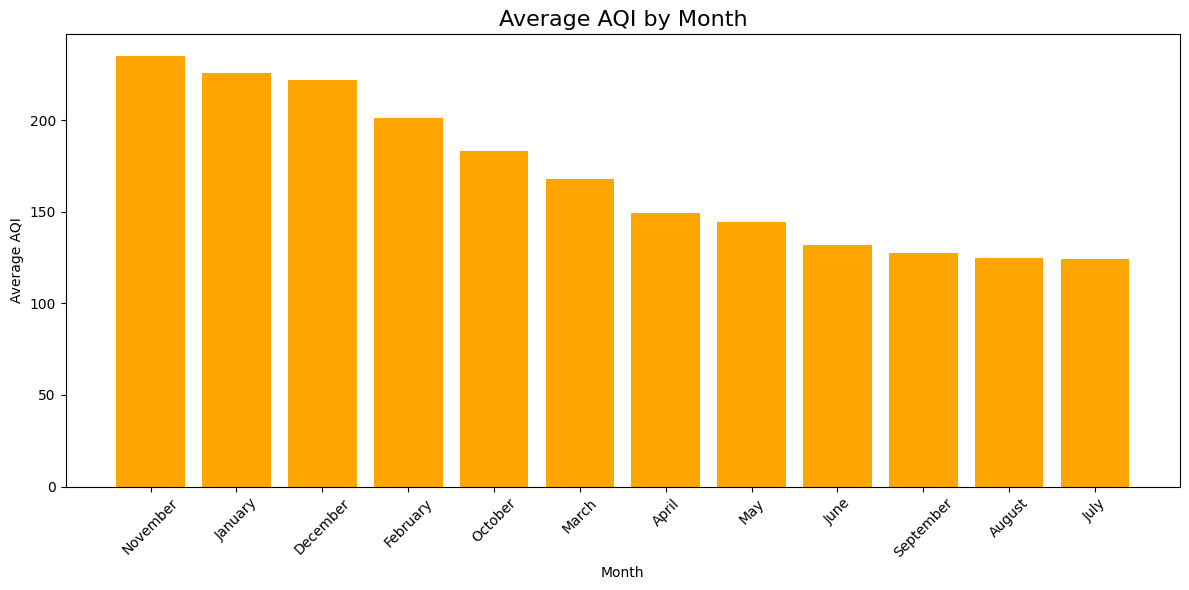

In [14]:
import matplotlib.pyplot as plt

# Plot 1 - Top 10 most polluted cities
top_cities = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_cities.index, top_cities.values, color='crimson')
plt.title('Top 10 Most Polluted Cities in India', fontsize=16)
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2 - AQI by month
monthly = df.groupby('Month')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.bar(monthly.index, monthly.values, color='orange')
plt.title('Average AQI by Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

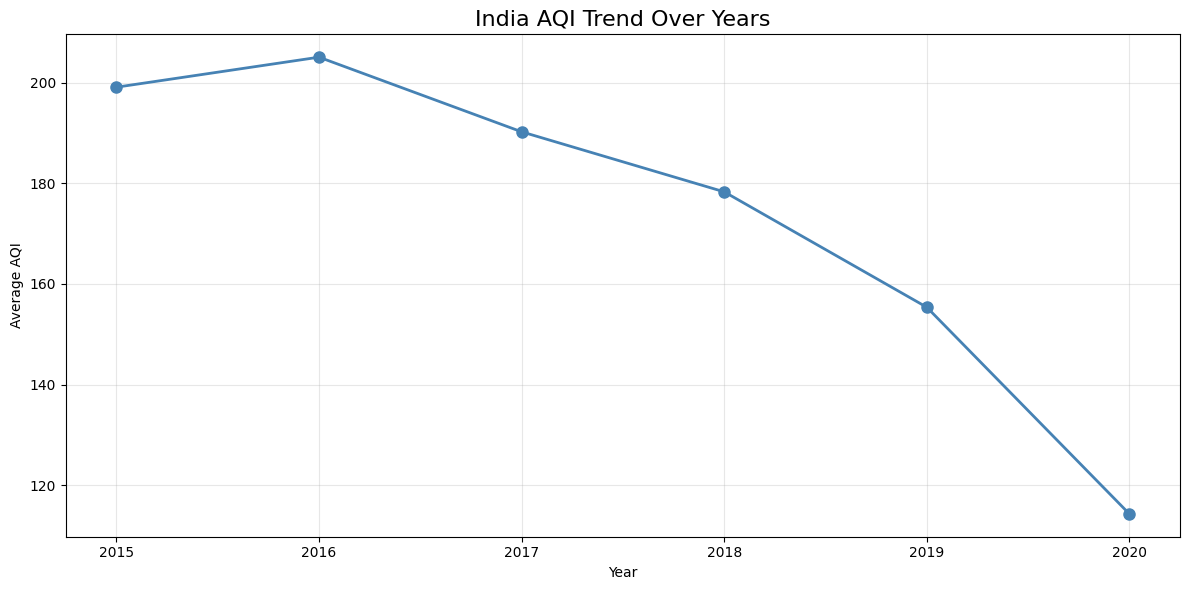

Yearly AQI values:
Year
2015    199.132393
2016    205.102639
2017    190.261521
2018    178.325787
2019    155.379158
2020    114.282183
Name: AQI, dtype: float64


In [15]:
# AQI trend over years
yearly = df.groupby('Year')['AQI'].mean()

plt.figure(figsize=(12,6))
plt.plot(yearly.index, yearly.values,
         marker='o', linewidth=2, color='steelblue', markersize=8)
plt.title('India AQI Trend Over Years', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Yearly AQI values:")
print(yearly)


In [16]:
# Check if Delhi spikes in November - Diwali effect
delhi = df[df['City'] == 'Delhi']
delhi_monthly = delhi.groupby('Month')['AQI'].mean().sort_values(ascending=False)
print("Delhi AQI by Month:")
print(delhi_monthly)

Delhi AQI by Month:
Month
November     401.953333
December     371.206452
January      360.387097
October      312.329032
February     298.829412
May          258.693548
April        248.444444
March        222.623656
June         199.752710
September    157.426667
August       140.896142
July         138.355691
Name: AQI, dtype: float64


In [17]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 96.1 MB/s eta 0:00:00


In [19]:
!pip install pyngrok -q

In [20]:
# Write the streamlit app to a file
app_code = '''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('city_day.csv')

# Clean
df = df.drop(columns=['Xylene', 'NH3', 'PM10','NO', 'NO2',
                       'NOx', 'CO', 'SO2', 'O3', 'Benzene',
                       'Toluene', 'AQI_Bucket'])
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['AQI'] = df.groupby('City')['AQI'].transform(
    lambda x: x.fillna(x.mean()))
df['PM2.5'] = df.groupby('City')['PM2.5'].transform(
    lambda x: x.fillna(x.mean()))

# App
st.title("🇮🇳 India Air Quality Dashboard")
st.markdown("Real AQI analysis across Indian cities")

# Sidebar filter
cities = st.sidebar.multiselect(
    "Select Cities",
    options=df['City'].unique(),
    default=['Delhi', 'Mumbai', 'Ahmedabad']
)

filtered = df[df['City'].isin(cities)]

# Metric cards
col1, col2, col3 = st.columns(3)
col1.metric("Average AQI", round(filtered['AQI'].mean(), 1))
col2.metric("Worst City",
    filtered.groupby('City')['AQI'].mean().idxmax())
col3.metric("Worst Month",
    filtered.groupby('Month')['AQI'].mean().idxmax())

# Chart 1 - City comparison
st.subheader("Average AQI by City")
city_aqi = filtered.groupby('City')['AQI'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(city_aqi.index, city_aqi.values, color='crimson')
ax.set_ylabel('Average AQI')
plt.xticks(rotation=45)
st.pyplot(fig)

# Chart 2 - Yearly trend
st.subheader("AQI Trend Over Years")
yearly = filtered.groupby('Year')['AQI'].mean()
fig2, ax2 = plt.subplots(figsize=(10,4))
ax2.plot(yearly.index, yearly.values,
         marker='o', color='steelblue', linewidth=2)
ax2.set_ylabel('Average AQI')
ax2.grid(True, alpha=0.3)
st.pyplot(fig2)

# Chart 3 - Monthly pattern
st.subheader("AQI by Month")
monthly = filtered.groupby('Month')['AQI'].mean().sort_values(ascending=False)
fig3, ax3 = plt.subplots(figsize=(10,4))
ax3.bar(monthly.index, monthly.values, color='orange')
ax3.set_ylabel('Average AQI')
plt.xticks(rotation=45)
st.pyplot(fig3)

# Raw data
if st.checkbox("Show Raw Data"):
    st.dataframe(filtered)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [22]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 22 packages in 3s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴

In [23]:
import subprocess
import threading
import time

# Start Streamlit
process = subprocess.Popen(
    ['streamlit', 'run', 'app.py', '--server.port', '8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

# Start localtunnel
tunnel = subprocess.Popen(
    ['lt', '--port', '8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(3)

output = tunnel.stdout.readline().decode()
print("Your dashboard URL:")
print(output)

Your dashboard URL:
your url is: https://little-wolves-try.loca.lt



In [27]:
# Stop previous processes
process.kill()
tunnel.kill()

# Restart with a different port
process2 = subprocess.Popen(
    ['streamlit', 'run', 'app.py',
     '--server.port', '8502',
     '--server.enableCORS', 'false',
     '--server.enableXsrfProtection', 'false'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

tunnel2 = subprocess.Popen(
    ['lt', '--port', '8502'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(3)
output = tunnel2.stdout.readline().decode()
print("New URL:")
print(output)

New URL:
your url is: https://shaggy-socks-design.loca.lt



In [28]:
from google.colab import files

# Download the app
files.download('app.py')

# Download the notebook

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>